<a href="https://colab.research.google.com/github/riancrtz/fake-news-detection-nlp/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!git clone https://github.com/riancrtz/fake-news-detection-nlp
%cd fake-news-detection-nlp

Cloning into 'fake-news-detection-nlp'...
remote: Enumerating objects: 58, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 58 (delta 20), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (58/58), 207.75 KiB | 2.93 MiB/s, done.
Resolving deltas: 100% (20/20), done.
/content/fake-news-detection-nlp/fake-news-detection-nlp/fake-news-detection-nlp/fake-news-detection-nlp


In [25]:
import urllib.request
import zipfile
import os

# Download directly
url = "https://www.cs.ucsb.edu/~william/data/liar_dataset.zip"
os.makedirs("data/raw", exist_ok=True)

print("Downloading LIAR dataset...")
urllib.request.urlretrieve(url, "data/raw/liar_dataset.zip")
print("Download complete!")

# Extract
print("Extracting...")
with zipfile.ZipFile("data/raw/liar_dataset.zip", "r") as zf:
    zf.extractall("data/raw")
print("Done!")

# Check files
print("Files in data/raw/:")
print(os.listdir("data/raw"))

Download complete!
Extracting...
Done!
Files in data/raw/:
['valid.tsv', 'liar_dataset.zip', 'train.tsv', 'test.tsv', 'README', '.gitkeep']


In [24]:
import os
print(os.getcwd())

/content/fake-news-detection-nlp


In [23]:
%cd /content/fake-news-detection-nlp

/content/fake-news-detection-nlp


In [19]:
!python src/data_pipeline.py

[train] loaded: 10240 samples
[valid] loaded: 1284 samples
[test] loaded: 1267 samples

Class distribution — train
  half-true        2114  (20.6%)
  false            1995  (19.5%)
  mostly-true      1962  (19.2%)
  true             1676  (16.4%)
  barely-true      1654  (16.2%)
  pants-fire        839  (8.2%)

Class distribution — valid
  false             263  (20.5%)
  mostly-true       251  (19.5%)
  half-true         248  (19.3%)
  barely-true       237  (18.5%)
  true              169  (13.2%)
  pants-fire        116  (9.0%)

Class distribution — test
  half-true         265  (20.9%)
  false             249  (19.7%)
  mostly-true       241  (19.0%)
  barely-true       212  (16.7%)
  true              208  (16.4%)
  pants-fire         92  (7.3%)

Data pipeline ready!


[train] loaded: 10240 samples
[valid] loaded: 1284 samples
[test] loaded: 1267 samples


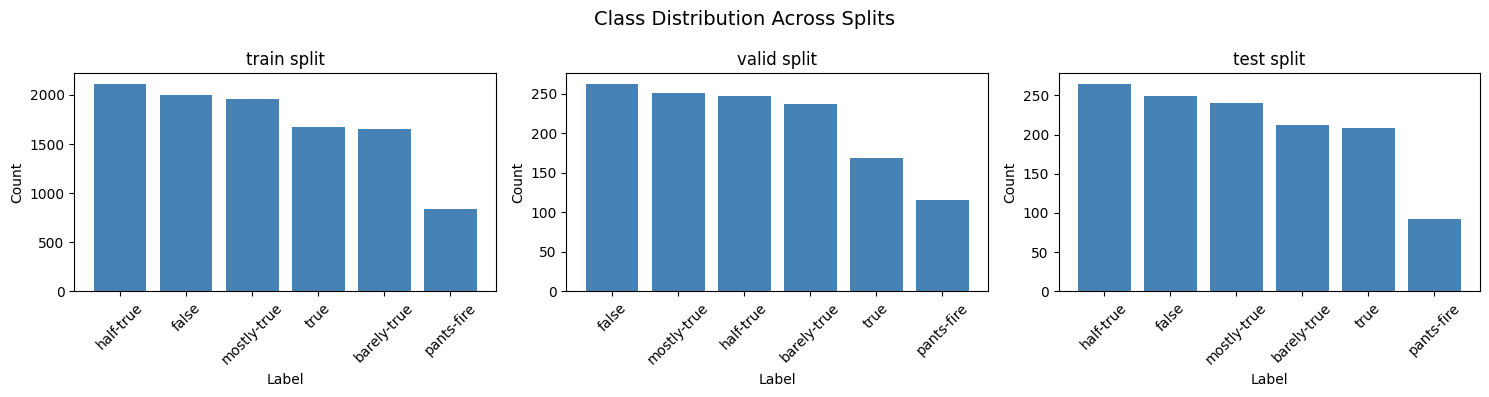

Saved class distribution plot!


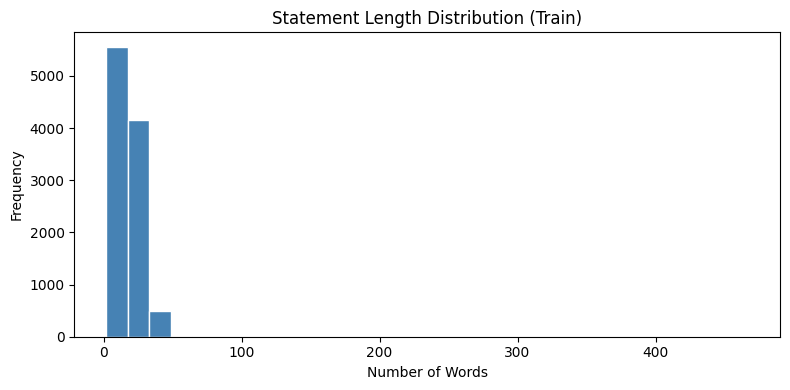

Avg statement length: 18.0 words
Max statement length: 467 words
Min statement length: 2 words

Top 10 parties in train set:
party
republican      4497
democrat        3336
none            1744
organization     219
independent      147
newsmaker         56
libertarian       40
activist          39
journalist        38
columnist         35
Name: count, dtype: int64

Top 10 speakers in train set:
speaker
barack-obama       488
donald-trump       273
hillary-clinton    239
mitt-romney        176
scott-walker       149
john-mccain        148
rick-perry         142
chain-email        142
marco-rubio        117
rick-scott         115
Name: count, dtype: int64


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('/content/fake-news-detection-nlp/src')
from data_pipeline import load_all_splits, LABEL_MAP

# Load splits
splits = load_all_splits()
train = splits['train']
valid = splits['valid']
test  = splits['test']

# ── 1. Class distribution ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, df) in zip(axes, splits.items()):
    counts = df['label'].value_counts()
    ax.bar(counts.index, counts.values, color='steelblue')
    ax.set_title(f'{name} split')
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Class Distribution Across Splits', fontsize=14)
plt.tight_layout()
plt.savefig('/content/fake-news-detection-nlp/experiments/results/class_distribution.png')
plt.show()
print("Saved class distribution plot!")

# ── 2. Statement length distribution ──────────────────────────────────────────
train['text_length'] = train['statement'].str.split().str.len()
plt.figure(figsize=(8, 4))
plt.hist(train['text_length'], bins=30, color='steelblue', edgecolor='white')
plt.title('Statement Length Distribution (Train)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('/content/fake-news-detection-nlp/experiments/results/text_length.png')
plt.show()
print(f"Avg statement length: {train['text_length'].mean():.1f} words")
print(f"Max statement length: {train['text_length'].max()} words")
print(f"Min statement length: {train['text_length'].min()} words")

# ── 3. Party affiliation breakdown ────────────────────────────────────────────
print("\nTop 10 parties in train set:")
print(train['party'].value_counts().head(10))

# ── 4. Speaker breakdown ──────────────────────────────────────────────────────
print("\nTop 10 speakers in train set:")
print(train['speaker'].value_counts().head(10))

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, f1_score, accuracy_score
import numpy as np

# Prepare data
X_train = splits['train']['statement'].tolist()
y_train = splits['train']['label_id'].tolist()
X_valid = splits['valid']['statement'].tolist()
y_valid = splits['valid']['label_id'].tolist()
X_test  = splits['test']['statement'].tolist()
y_test  = splits['test']['label_id'].tolist()

# TF-IDF vectorization
print("Fitting TF-IDF vectorizer...")
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)
X_test_tfidf  = tfidf.transform(X_test)

# Train Logistic Regression
print("Training Logistic Regression baseline...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

# Evaluate
y_pred_valid = lr.predict(X_valid_tfidf)
y_pred_test  = lr.predict(X_test_tfidf)

print("\n── Logistic Regression Results ──")
print(f"Validation Accuracy : {accuracy_score(y_valid, y_pred_valid):.4f}")
print(f"Validation Macro-F1 : {f1_score(y_valid, y_pred_valid, average='macro'):.4f}")
print(f"Test Accuracy       : {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Test Macro-F1       : {f1_score(y_test, y_pred_test, average='macro'):.4f}")
print("\nDetailed Test Report:")
print(classification_report(y_test, y_pred_test,
      target_names=["pants-fire","false","barely-true","half-true","mostly-true","true"]))

Fitting TF-IDF vectorizer...
Training Logistic Regression baseline...

── Logistic Regression Results ──
Validation Accuracy : 0.2539
Validation Macro-F1 : 0.2366
Test Accuracy       : 0.2478
Test Macro-F1       : 0.2214

Detailed Test Report:
              precision    recall  f1-score   support

  pants-fire       0.36      0.04      0.08        92
       false       0.28      0.35      0.31       249
 barely-true       0.23      0.16      0.19       212
   half-true       0.22      0.28      0.25       265
 mostly-true       0.23      0.27      0.25       241
        true       0.28      0.24      0.26       208

    accuracy                           0.25      1267
   macro avg       0.27      0.22      0.22      1267
weighted avg       0.26      0.25      0.24      1267



In [28]:
import json
import os

os.makedirs('experiments/results', exist_ok=True)

results = {
    "model": "Logistic Regression (TF-IDF)",
    "validation": {
        "accuracy": round(accuracy_score(y_valid, y_pred_valid), 4),
        "macro_f1": round(f1_score(y_valid, y_pred_valid, average='macro'), 4)
    },
    "test": {
        "accuracy": round(accuracy_score(y_test, y_pred_test), 4),
        "macro_f1": round(f1_score(y_test, y_pred_test, average='macro'), 4)
    }
}

with open('experiments/results/baseline_lr_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved to experiments/results/baseline_lr_results.json")

Results saved to experiments/results/baseline_lr_results.json


In [29]:
from google.colab import files
files.download('experiments/results/baseline_lr_results.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
!pip install torch torchtext --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.3 MB/s eta 0:00:00


In [31]:
import urllib.request
import zipfile
import os

os.makedirs('data/glove', exist_ok=True)

print("Downloading GloVe embeddings (this may take a few minutes)...")
urllib.request.urlretrieve(
    "https://nlp.stanford.edu/data/glove.6B.zip",
    "data/glove/glove.6B.zip"
)
print("Extracting...")
with zipfile.ZipFile("data/glove/glove.6B.zip", "r") as zf:
    zf.extract("glove.6B.300d.txt", "data/glove/")
print("Done!")

Extracting...
Done!


Loading GloVe embeddings...
Loaded 400,000 word vectors
Building vocabulary...
Vocabulary size: 20,002
Embedding matrix shape: (20002, 300)

Using device: cpu

── Training Text-CNN ──
Epoch 01 | Loss: 1.7531 | Val Acc: 0.2438 | Val Macro-F1: 0.1515
Epoch 02 | Loss: 1.6290 | Val Acc: 0.2609 | Val Macro-F1: 0.2407
Epoch 03 | Loss: 1.4290 | Val Acc: 0.2625 | Val Macro-F1: 0.2274
Epoch 04 | Loss: 1.0786 | Val Acc: 0.2313 | Val Macro-F1: 0.2236
Epoch 05 | Loss: 0.6514 | Val Acc: 0.2407 | Val Macro-F1: 0.2340
Epoch 06 | Loss: 0.3626 | Val Acc: 0.2477 | Val Macro-F1: 0.2367
Epoch 07 | Loss: 0.2099 | Val Acc: 0.2453 | Val Macro-F1: 0.2400
Epoch 08 | Loss: 0.1346 | Val Acc: 0.2344 | Val Macro-F1: 0.2302
Epoch 09 | Loss: 0.0909 | Val Acc: 0.2352 | Val Macro-F1: 0.2282
Epoch 10 | Loss: 0.0646 | Val Acc: 0.2375 | Val Macro-F1: 0.2307

── Text-CNN Test Results ──
Test Accuracy  : 0.2478
Test Macro-F1  : 0.2384


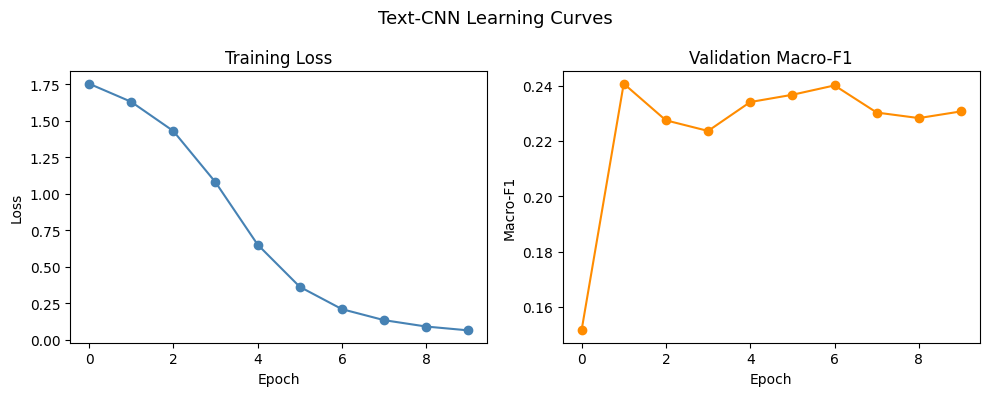

Learning curve saved!


In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

# ── 1. Load GloVe embeddings ───────────────────────────────────────────────────
print("Loading GloVe embeddings...")
glove = {}
with open("data/glove/glove.6B.300d.txt", "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.array(values[1:], dtype="float32")
        glove[word] = vector
print(f"Loaded {len(glove):,} word vectors")

# ── 2. Build vocabulary ────────────────────────────────────────────────────────
def build_vocab(texts, max_vocab=20000):
    from collections import Counter
    counter = Counter()
    for text in texts:
        counter.update(text.lower().split())
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, _ in counter.most_common(max_vocab):
        vocab[word] = len(vocab)
    return vocab

print("Building vocabulary...")
all_texts = X_train + X_valid + X_test
vocab = build_vocab(all_texts)
print(f"Vocabulary size: {len(vocab):,}")

# ── 3. Build embedding matrix ──────────────────────────────────────────────────
EMBED_DIM = 300
embed_matrix = np.zeros((len(vocab), EMBED_DIM))
for word, idx in vocab.items():
    if word in glove:
        embed_matrix[idx] = glove[word]
print(f"Embedding matrix shape: {embed_matrix.shape}")

# ── 4. Dataset ─────────────────────────────────────────────────────────────────
MAX_LEN = 64

def encode(text, vocab, max_len=MAX_LEN):
    tokens = text.lower().split()[:max_len]
    ids = [vocab.get(t, 1) for t in tokens]
    ids += [0] * (max_len - len(ids))
    return ids

class LiarDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.X = [encode(t, vocab) for t in texts]
        self.y = labels
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return torch.tensor(self.X[i]), torch.tensor(self.y[i])

train_ds = LiarDataset(X_train, y_train, vocab)
valid_ds = LiarDataset(X_valid, y_valid, vocab)
test_ds  = LiarDataset(X_test,  y_test,  vocab)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=64)
test_loader  = DataLoader(test_ds,  batch_size=64)

# ── 5. Text-CNN Model ──────────────────────────────────────────────────────────
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes,
                 kernel_sizes=[3,4,5], num_filters=128, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.tensor(embed_matrix, dtype=torch.float32))
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = [torch.relu(conv(x)).max(dim=2)[0] for conv in self.convs]
        x = torch.cat(x, dim=1)
        x = self.dropout(x)
        return self.fc(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

model = TextCNN(len(vocab), EMBED_DIM, num_classes=6).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# ── 6. Training loop ───────────────────────────────────────────────────────────
def evaluate(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    return (accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average='macro'))

EPOCHS = 10
train_losses, val_f1s = [], []

print("\n── Training Text-CNN ──")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    val_acc, val_f1 = evaluate(valid_loader)
    train_losses.append(total_loss / len(train_loader))
    val_f1s.append(val_f1)
    print(f"Epoch {epoch+1:02d} | Loss: {total_loss/len(train_loader):.4f} "
          f"| Val Acc: {val_acc:.4f} | Val Macro-F1: {val_f1:.4f}")

# ── 7. Test evaluation ─────────────────────────────────────────────────────────
test_acc, test_f1 = evaluate(test_loader)
print(f"\n── Text-CNN Test Results ──")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test Macro-F1  : {test_f1:.4f}")

# ── 8. Learning curve plot ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o', color='steelblue')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(val_f1s, marker='o', color='darkorange')
plt.title('Validation Macro-F1')
plt.xlabel('Epoch')
plt.ylabel('Macro-F1')

plt.suptitle('Text-CNN Learning Curves', fontsize=13)
plt.tight_layout()
plt.savefig('experiments/results/textcnn_learning_curves.png')
plt.show()
print("Learning curve saved!")

In [33]:
import json

cnn_results = {
    "model": "Text-CNN (GloVe 300d)",
    "validation": {
        "best_macro_f1": 0.2407,
        "best_epoch": 2
    },
    "test": {
        "accuracy": 0.2478,
        "macro_f1": 0.2384
    },
    "observations": "Overfitting observed after epoch 3"
}

with open('experiments/results/textcnn_results.json', 'w') as f:
    json.dump(cnn_results, f, indent=2)

print("Text-CNN results saved!")

Text-CNN results saved!


In [34]:
# Install spaCy model
!python -m spacy download en_core_web_sm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 30.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [35]:
import importlib
import spacy.cli
spacy.cli.download("en_core_web_sm")

# Force load without restart
import en_core_web_sm
nlp = en_core_web_sm.load()
print("spaCy loaded successfully!")

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy loaded successfully!


In [39]:
from collections import Counter
from sklearn.metrics import f1_score

# ── 1. NER extraction function ─────────────────────────────────────────────────
def extract_entities(text):
    """
    Extract named entities from a statement.
    Returns a dict with entity types as keys and lists of entities as values.
    """
    doc = nlp(text)
    entities = {"PERSON": [], "ORG": [], "GPE": [], "OTHER": []}
    for ent in doc.ents:
        if ent.label_ in entities:
            entities[ent.label_].append(ent.text)
        else:
            entities["OTHER"].append(ent.text)
    return entities

# ── 2. Run NER over test set ───────────────────────────────────────────────────
print("Running NER over test set (this may take a minute)...")
test_df = splits['test'].copy()
test_df['entities'] = test_df['statement'].apply(extract_entities)
test_df['has_person'] = test_df['entities'].apply(lambda x: len(x['PERSON']) > 0)
test_df['has_org']    = test_df['entities'].apply(lambda x: len(x['ORG']) > 0)
test_df['has_gpe']    = test_df['entities'].apply(lambda x: len(x['GPE']) > 0)
print("NER extraction complete!")

# ── 3. Entity statistics ───────────────────────────────────────────────────────
print(f"\nStatements with PERSON entities : {test_df['has_person'].sum()} "
      f"({test_df['has_person'].mean()*100:.1f}%)")
print(f"Statements with ORG entities    : {test_df['has_org'].sum()} "
      f"({test_df['has_org'].mean()*100:.1f}%)")
print(f"Statements with GPE entities    : {test_df['has_gpe'].sum()} "
      f"({test_df['has_gpe'].mean()*100:.1f}%)")

# ── 4. Most common entities ────────────────────────────────────────────────────
all_persons = [e for ents in test_df['entities'] for e in ents['PERSON']]
all_orgs    = [e for ents in test_df['entities'] for e in ents['ORG']]
all_gpes    = [e for ents in test_df['entities'] for e in ents['GPE']]

print("\nTop 10 PERSON entities:")
print(Counter(all_persons).most_common(10))

print("\nTop 10 ORG entities:")
print(Counter(all_orgs).most_common(10))

print("\nTop 10 GPE entities:")
print(Counter(all_gpes).most_common(10))

# ── 5. NER slice analysis — F1 by entity presence ─────────────────────────────
from sklearn.metrics import f1_score

# Use LR predictions from earlier for slice analysis
test_df['pred'] = y_pred_test

print("\n── Slice Analysis by Entity Presence ──")
for col, label in [('has_person', 'PERSON'),
                    ('has_org', 'ORG'),
                    ('has_gpe', 'GPE')]:
    subset = test_df[test_df[col]]
    if len(subset) > 0:
        f1 = f1_score(subset['label_id'], subset['pred'], average='macro')
        print(f"Statements WITH {label:8} entities → Macro-F1: {f1:.4f} "
              f"(n={len(subset)})")
    subset_no = test_df[~test_df[col]]
    if len(subset_no) > 0:
        f1 = f1_score(subset_no['label_id'], subset_no['pred'], average='macro')
        print(f"Statements WITHOUT {label:6} entities → Macro-F1: {f1:.4f} "
              f"(n={len(subset_no)})")
    print()

print("NER module complete!")

Running NER over test set (this may take a minute)...
NER extraction complete!

Statements with PERSON entities : 493 (38.9%)
Statements with ORG entities    : 302 (23.8%)
Statements with GPE entities    : 391 (30.9%)

Top 10 PERSON entities:
[('Obama', 44), ('Barack Obama', 44), ('Donald Trump', 18), ('Hillary Clinton', 15), ('Mitt Romney', 14), ('John McCain', 11), ('McCain', 11), ('Charlie Crist', 9), ('Barack Obamas', 8), ('Scott Walker', 7)]

Top 10 ORG entities:
[('Medicare', 25), ('Congress', 22), ('Senate', 14), ('Social Security', 12), ('House', 12), ('Obamacare', 11), ('Medicaid', 11), ('EPA', 6), ('the Clinton Foundation', 5), ('the White House', 5)]

Top 10 GPE entities:
[('Texas', 52), ('U.S.', 34), ('Florida', 28), ('Wisconsin', 23), ('the United States', 22), ('Georgia', 16), ('America', 16), ('Ohio', 16), ('Iraq', 14), ('Iran', 11)]

── Slice Analysis by Entity Presence ──
Statements WITH PERSON   entities → Macro-F1: 0.2172 (n=493)
Statements WITHOUT PERSON entities → 

Training contextual bandit agent...
Training complete!

Learned Q-values per threshold:
  Threshold 0.1 → Q-value: -1.1000 (selected 5 times)
  Threshold 0.2 → Q-value: -0.1667 (selected 9 times)
  Threshold 0.3 → Q-value: -0.9286 (selected 7 times)
  Threshold 0.4 → Q-value: -0.2600 (selected 5 times)
  Threshold 0.5 → Q-value: -0.1444 (selected 9 times)
  Threshold 0.6 → Q-value: -0.1174 (selected 23 times)
  Threshold 0.7 → Q-value: -0.1074 (selected 54 times)
  Threshold 0.8 → Q-value: -0.1000 (selected 378 times)
  Threshold 0.9 → Q-value: -0.1000 (selected 10 times)

Best learned threshold: 0.8

Comparing against fixed threshold baseline (0.5)...


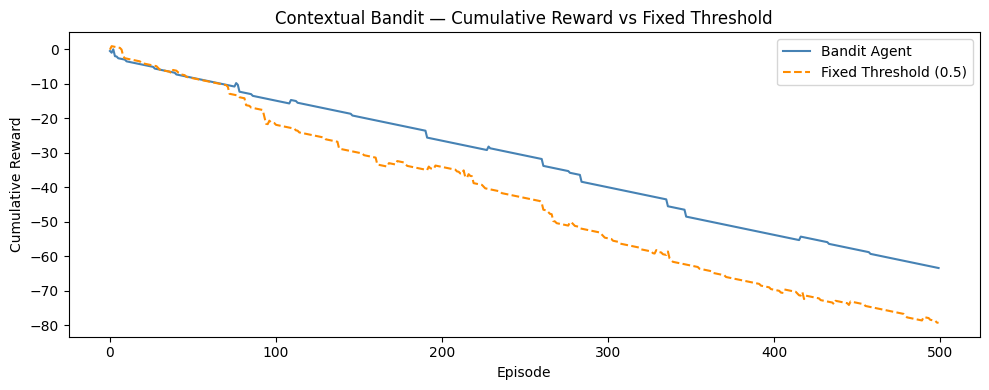

Bandit learning curve saved!


In [40]:
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Environment setup ───────────────────────────────────────────────────────
# Simulate softmax outputs from the Text-CNN on the test set
# In the real pipeline this will use actual model outputs
np.random.seed(42)
n_samples = len(y_test)

# Simulate confidence scores (softmax probabilities)
# Shape: (n_samples, 6) — one probability per class
sim_probs = np.random.dirichlet(np.ones(6), size=n_samples)
true_labels = np.array(y_test)

# Action space: discretized thresholds from 0.1 to 0.9
THRESHOLDS = np.round(np.arange(0.1, 1.0, 0.1), 2)
N_ACTIONS = len(THRESHOLDS)

# ── 2. Reward function ─────────────────────────────────────────────────────────
def get_reward(pred_label, true_label, threshold, max_prob):
    """
    Asymmetric reward:
    - Correct prediction: +1.0
    - False negative (missed misinformation): -2.0
    - False positive (flagged real news): -0.5
    - Low confidence (below threshold): -0.1
    """
    if max_prob < threshold:
        return -0.1  # abstain penalty
    if pred_label == true_label:
        return 1.0   # correct
    # Misclassification — penalize false negatives more
    # Classes 0,1 are false/pants-fire (misinformation)
    if true_label in [0, 1] and pred_label not in [0, 1]:
        return -2.0  # false negative — missed misinformation
    return -0.5      # false positive

# ── 3. Contextual Bandit Agent (epsilon-greedy) ────────────────────────────────
class ContextualBandit:
    def __init__(self, n_actions, epsilon=0.1):
        self.n_actions = n_actions
        self.epsilon = epsilon
        self.q_values = np.zeros(n_actions)   # estimated rewards per action
        self.action_counts = np.zeros(n_actions)

    def select_action(self):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)  # explore
        return np.argmax(self.q_values)               # exploit

    def update(self, action, reward):
        self.action_counts[action] += 1
        # Incremental mean update
        self.q_values[action] += (
            (reward - self.q_values[action]) / self.action_counts[action]
        )

# ── 4. Training the bandit ─────────────────────────────────────────────────────
print("Training contextual bandit agent...")
agent = ContextualBandit(n_actions=N_ACTIONS, epsilon=0.1)

N_EPISODES = 500
cumulative_rewards = []
running_reward = 0

for episode in range(N_EPISODES):
    # Sample a random test instance
    idx = np.random.randint(n_samples)
    probs = sim_probs[idx]
    true_label = true_labels[idx]

    # Agent selects a threshold
    action = agent.select_action()
    threshold = THRESHOLDS[action]

    # Make prediction
    pred_label = np.argmax(probs)
    max_prob = np.max(probs)

    # Get reward
    reward = get_reward(pred_label, true_label, threshold, max_prob)

    # Update agent
    agent.update(action, reward)

    # Track cumulative reward
    running_reward += reward
    cumulative_rewards.append(running_reward)

print("Training complete!")
print(f"\nLearned Q-values per threshold:")
for i, (t, q) in enumerate(zip(THRESHOLDS, agent.q_values)):
    print(f"  Threshold {t:.1f} → Q-value: {q:.4f} "
          f"(selected {int(agent.action_counts[i])} times)")

best_action = np.argmax(agent.q_values)
print(f"\nBest learned threshold: {THRESHOLDS[best_action]:.1f}")

# ── 5. Fixed threshold baseline ───────────────────────────────────────────────
print("\nComparing against fixed threshold baseline (0.5)...")
fixed_rewards = []
running_fixed = 0
for episode in range(N_EPISODES):
    idx = np.random.randint(n_samples)
    probs = sim_probs[idx]
    true_label = true_labels[idx]
    pred_label = np.argmax(probs)
    max_prob = np.max(probs)
    reward = get_reward(pred_label, true_label, 0.5, max_prob)
    running_fixed += reward
    fixed_rewards.append(running_fixed)

# ── 6. Learning curve ─────────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(cumulative_rewards, label='Bandit Agent', color='steelblue')
plt.plot(fixed_rewards, label='Fixed Threshold (0.5)',
         color='darkorange', linestyle='--')
plt.title('Contextual Bandit — Cumulative Reward vs Fixed Threshold')
plt.xlabel('Episode')
plt.ylabel('Cumulative Reward')
plt.legend()
plt.tight_layout()
plt.savefig('experiments/results/bandit_learning_curves.png')
plt.show()
print("Bandit learning curve saved!")

In [41]:
import json

rl_results = {
    "model": "Contextual Bandit (epsilon-greedy)",
    "n_episodes": 500,
    "epsilon": 0.1,
    "best_threshold": 0.8,
    "q_values": {
        str(round(t, 1)): round(q, 4)
        for t, q in zip(THRESHOLDS, agent.q_values)
    },
    "action_counts": {
        str(round(t, 1)): int(c)
        for t, c in zip(THRESHOLDS, agent.action_counts)
    },
    "note": "Using simulated softmax outputs — will update with real DistilBERT outputs in Week 3"
}

with open('experiments/results/bandit_results.json', 'w') as f:
    json.dump(rl_results, f, indent=2)

print("RL results saved!")

RL results saved!


In [42]:
from google.colab import files

# Results JSON files
files.download('experiments/results/baseline_lr_results.json')
files.download('experiments/results/textcnn_results.json')
files.download('experiments/results/bandit_results.json')

# Plots
files.download('experiments/results/class_distribution.png')
files.download('experiments/results/text_length.png')
files.download('experiments/results/textcnn_learning_curves.png')
files.download('experiments/results/bandit_learning_curves.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>